In [1]:
import numpy as np
import minterpy as mp
import pandas as pd
import cvxpy as cp
from matplotlib import pyplot as plt

import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector

In [2]:
# Generate multiindices of different degree on each dimension.
# Useful when the available data does not have same resolution
# along different dimensions.

from minterpy.core.utils import get_exponent_matrix
from minterpy.jit_compiled_utils import lp_norm_for_exponents

def poly_evaluate_at(n_poly, eval_points, lower_bounds, upper_bounds):
    N_points, spatial_dim = eval_points.shape

    result = np.zeros(N_points)
    for p in range(N_points):
        coord = eval_points[p,:]
        resized_coord = (np.divide(coord - lower_bounds, upper_bounds - lower_bounds) * 2.0) - 1.0
        result[p] = n_poly(resized_coord)

    return result


def gen_multi_indices(spatial_dimension, degree_along_dim, lp_degree):
    max_exponent = np.max(degree_along_dim)
    exponents = get_exponent_matrix(spatial_dimension, max_exponent, lp_degree)
    N, m = exponents.shape

    # initial filtering step
    mask = [True] * N
    for i in range(m):
        dim_mask = exponents[:,i] <= degree_along_dim[i]
        mask = mask & dim_mask

    reduced_exp = exponents[mask,:]

    return reduced_exp

In [10]:
def lasso_fit_data(sample_points, function_vals, poly_degree_along,
                           weighted=True):
    """ Regression with L1 fitting for mass spec data.

    Note: function_vals has to be provided in actual scale as we take the log2 of it here.
    Parameters
    ----------
    sample_points : coordinates of data
    function_vals : value at the coordinates (eg. intensity)
    poly_degree_along : array specifying the poly degree along each data coordinate
    weighted : weighting with function value enabled if True

    Returns
    -------
    A polynomial (in Newton basis)
    """

    spatial_dim = sample_points.shape[1]

    if len(poly_degree_along) != spatial_dim:
        raise ValueError(f"Poly degrees not correctly specified. \
                            Expected array with {spatial_dim} entries. Got {len(poly_degree_along)}.")

    custom_exponents = gen_multi_indices(spatial_dim, poly_degree_along, 2.0)

    coord = np.array(sample_points, dtype=np.float_)

    lower_bounds = np.round(np.amin(coord, axis=0))
    upper_bounds = np.round(np.amax(coord, axis=0))+1.0

    # Convert coordinates to within the [-1,1] domain
    resized_coord = (np.divide(coord - lower_bounds, upper_bounds - lower_bounds) * 2.0) - 1.0

    ## The log of the intensities
    F = np.log2(function_vals)

    # Create unisolvent nodes with the custom set of exponents
    mi = mp.MultiIndexSet(custom_exponents)
    grid = mp.Grid(mi)
    regressor = mp.Regression(grid, verbose=False)
    regressor.cache_transform(resized_coord)

    R = regressor.regression_matrix
    l2c = mp.transformations.LagrangeToCanonical(regressor._lagrange_poly).transformation_operator

    # Create two scalar optimization variables.
    x = cp.Variable(R.shape[1])

    if weighted:
        wmat = np.diag(np.sqrt(function_vals))
    else:
        wmat = np.eye(R.shape[0])

    Rmat = wmat @ R
    Fmat = F @ wmat
    # Form objective.
    loss1 = cp.sum_squares(Rmat @ x - Fmat)
    loss2 = cp.sum(cp.abs(l2c @ x))
    obj = cp.Minimize(loss1 + loss2)

    # Form and solve problem.
    prob = cp.Problem(obj)
    prob.solve()

    print(f"Optimizer result : {prob.value}")

    sparse_lag_poly = mp.LagrangePolynomial.from_poly(regressor._lagrange_poly, new_coeffs=x.value)
    l2n = mp.get_transformation(sparse_lag_poly, mp.NewtonPolynomial)
    sparse_poly_model = l2n()

    return sparse_poly_model

## PCO Data

In [12]:
tmp  = pd.read_csv(r"20211004_PCO-sn2_FA.csv")
df = tmp


# df = tmp[((tmp['FA_DB_y'] == 0) & (tmp['FA_iso_y'] > 0)) == False] # filter out artificial curves with iso>0 and db=0
cols = ['CE', 'FA_C_y', 'FA_DB_y', 'FA_iso_y']

sample_points_pco = df[cols].to_numpy()
# function_vals_log = df['norm_Intensity'].to_numpy() # This is already in log scale
# function_vals_pco = pow(2,function_vals_log)

function_vals_pco = df['norm_Intensity'].to_numpy() # This is already in log scale

In [13]:
len(function_vals_pco)

1871

###### Get overview of input

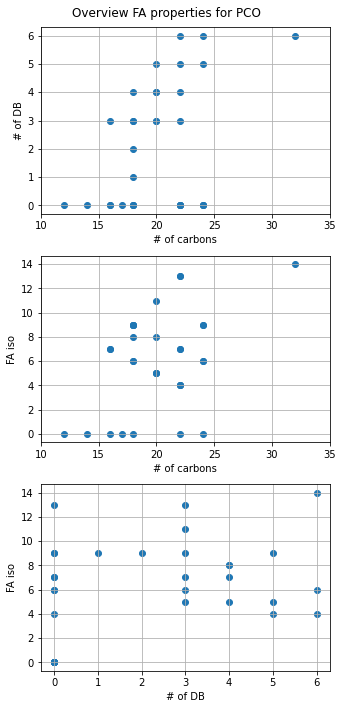

In [6]:
## get dataframe with needed properties
overview_df = df[['FA_C_y', 'FA_DB_y', 'FA_iso_y']].drop_duplicates()

fig, ax = plt.subplots(3,1, figsize=(5,10))

fig.suptitle('Overview FA properties for PCO')

ax = plt.subplot(3,1,1)
plt.scatter(overview_df.FA_C_y, overview_df.FA_DB_y)
ax.set_xlim(10,35, 'r')
ax.set_xlabel('# of carbons')
ax.set_ylabel('# of DB')
ax.grid(which='both')

ax = plt.subplot(3,1,2)
plt.scatter(overview_df.FA_C_y, overview_df.FA_iso_y)
ax.set_xlim(10,35)
ax.set_xlabel('# of carbons')
ax.set_ylabel('FA iso')
ax.grid(which='both')


ax = plt.subplot(3,1,3)
plt.scatter(overview_df.FA_DB_y, overview_df.FA_iso_y)
# ax2.set_xlim(0,6)
ax.set_xlabel('# of DB')
ax.set_ylabel('FA iso')
ax.grid(which='both')

plt.tight_layout()
# plt.savefig("./figures/paper_draft/20220530_PCO_fullset_overview.jpg")
plt.show()

In [11]:
sparse_poly_model_pco = lasso_fit_data(sample_points_pco,
                                       function_vals_pco,
                                       poly_degree_along=[9,2,2,2],
                                       weighted=True)

AttributeError: module 'minterpy' has no attribute 'Regression'

In [8]:
lower_bounds = np.round(np.amin(sample_points_pco, axis=0))
upper_bounds = np.round(np.amax(sample_points_pco, axis=0))+1.0

eval_vals = poly_evaluate_at(sparse_poly_model_pco, sample_points_pco, lower_bounds, upper_bounds)

abs_errs = pow(2,eval_vals) - function_vals_pco
rel_errs = np.divide(abs_errs, function_vals_pco)

L2_error = np.linalg.norm(rel_errs, 1)/len(rel_errs)
Linf_error = np.max(np.abs(rel_errs))
print(f"L_2 error of fitting SYM dataset = {L2_error}")

print(f"L_inf error of fitting SYM dataset = {Linf_error}")
plt.plot(function_vals_pco)
plt.plot(pow(2,eval_vals))
# plt.plot(rel_errs)
# plt.xlim(900,1100)
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

## Visualizing all training spectra

In [9]:
### Select dataset and polynomial model here
sample_points = sample_points_pco
function_vals = function_vals_pco
poly_model = sparse_poly_model_pco


NameError: name 'sparse_poly_model_pco' is not defined

In [10]:
l_uni=[]
for i in sample_points[:,1:].tolist():
    if (len(l_uni) == 0) or (i != l_uni[-1]):
        l_uni.append(i)
l_uni

[[12, 0, 0],
 [14, 0, 0],
 [16, 0, 0],
 [16, 0, 7],
 [17, 0, 0],
 [18, 0, 0],
 [18, 0, 9],
 [18, 0, 6],
 [18, 2, 9],
 [18, 3, 9],
 [18, 3, 6],
 [18, 4, 8],
 [20, 3, 11],
 [20, 3, 5],
 [20, 4, 5],
 [20, 4, 8],
 [20, 5, 5],
 [22, 0, 0],
 [22, 0, 13],
 [22, 0, 7],
 [22, 0, 4],
 [22, 3, 13],
 [22, 4, 7],
 [22, 5, 4],
 [22, 6, 4],
 [24, 0, 0],
 [24, 5, 9],
 [24, 6, 6],
 [18, 1, 9],
 [32, 6, 14],
 [16, 3, 7],
 [24, 0, 9],
 [24, 0, 6]]

In [11]:
# train_combinations = sample_points[np.where(sample_points[:,0]==10),1:][0]
# num_combinations = train_combinations.shape[0]
# print(f"{num_combinations} different (C,DB,ISO) in training")

# fig, ax = plt.subplots(num_combinations,1)

# fig.set_size_inches(8,6*num_combinations)
# for idx in range(num_combinations):
#     fa_c = train_combinations[idx,0]
#     fa_db = train_combinations[idx,1]
#     fa_iso = train_combinations[idx,2]

#     # # get fit data
#     ce = np.linspace(11, 69, 100)

#     ni_eval_points = np.zeros((100, 4))
#     ni_eval_points[:,0] = ce
#     ni_eval_points[:,1] = fa_c
#     ni_eval_points[:,2] = fa_db
#     ni_eval_points[:,3] = fa_iso

#     lower_bounds = np.round(np.amin(sample_points, axis=0))
#     upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

#     ni_dp_reg_vals = poly_evaluate_at(poly_model, ni_eval_points, lower_bounds, upper_bounds)

#     # get measured values
#     fi_sample_points = []
#     fi_function_vals = []
#     for i in range(len(function_vals)):
#         if sample_points[i,1] == fa_c and sample_points[i,2] == fa_db and sample_points[i,3] == fa_iso:
#             fi_sample_points.append([sample_points[i,0]])
#             fi_function_vals.append(function_vals[i])


#     ax[idx].set_title(f"Normalized intensity curve for FA {fa_c}:{fa_db}({fa_iso})")

#     ax[idx].plot(ce,pow(2,ni_dp_reg_vals), label='fitted')
#     ax[idx].plot(fi_sample_points, fi_function_vals, '.', label='measured', alpha=.66)

#     # plt.ylim(0)
#     ax[idx].set_xlabel('Normalized collision energy, %')
#     ax[idx].set_ylabel('Normalized intensity, %')
#     ax[idx].legend()


## Contour plot

In [12]:
lower_bounds = np.round(np.amin(sample_points_pco, axis=0))
upper_bounds = np.round(np.amax(sample_points_pco, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 12 #lower_bounds[1]
yhi = 32 #upper_bounds[1]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_db = 0
fa_iso = 0

num_points_in_grid = len(coords_y)

eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x ## NCE
eval_points[:,1] = coords_y ## FA_C
eval_points[:,2] = fa_db
eval_points[:,3] = fa_iso


eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of saturated FA fragments\nInt = f(NCE, #C) with #DB=0 and iso=0")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of carbon atoms on FA")
# plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar().set_label('Normalized intensity, %')

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FAsat_coutour.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

In [13]:
lower_bounds = np.round(np.amin(sample_points_pco, axis=0))
upper_bounds = np.round(np.amax(sample_points_pco, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 12 #lower_bounds[1]
yhi = 32 #upper_bounds[1]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_db = 0
fa_iso = 0

num_points_in_grid = len(coords_y)

eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x ## NCE
eval_points[:,1] = coords_y ## FA_C
eval_points[:,2] = fa_db
eval_points[:,3] = fa_iso


eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, lower_bounds, upper_bounds)

# Reshape eval_vals to match the grid dimensions
Z = pow(2,eval_vals.reshape((100,100)))

Z_masked = np.ma.masked_array(Z, Z < 0)

# Create a heatmap (2D plot)
plt.imshow(Z_masked, origin='lower', extent=[xlo, xhi, ylo, yhi], aspect='auto', cmap='viridis')
plt.colorbar(label='Relative intensity, %')
plt.xlabel('Normalized collision energy, %')
plt.ylabel('Number of carbon atoms')

# Contour lines (optional)
contour_levels = np.linspace(np.min(Z), np.max(Z), 10)
plt.contour(X, Y, Z_masked, levels=contour_levels, colors='k', linewidths=0.5)


plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FAsat_2D.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

In [14]:
# in case 3D is interesting
# to generate a 3d plot of the contour plot

# %matplotlib widget

# from mpl_toolkits.mplot3d import Axes3D


from scipy.spatial import Delaunay

# Your existing code

lower_bounds = np.round(np.amin(sample_points_pco, axis=0))
upper_bounds = np.round(np.amax(sample_points_pco, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 12 #lower_bounds[1]
yhi = 32 #upper_bounds[1]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_db = 0
fa_iso = 0

num_points_in_grid = len(coords_y)

eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x ## NCE
eval_points[:,1] = coords_y ## FA_C
eval_points[:,2] = fa_db
eval_points[:,3] = fa_iso

eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, lower_bounds, upper_bounds)

# Additional code for the 3D plot
Z = eval_vals.reshape(X.shape)

# Create a mask for Z values >= 0
mask = Z >= 0

fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Compute the Delaunay triangulation of the data points
triang = Delaunay(np.vstack((X[mask], Y[mask])).T)

# Plot the smooth surface using trisurf
surf = ax.plot_trisurf(X[mask].ravel(), Y[mask].ravel(), Z[mask].ravel(), triangles=triang.simplices, cmap='viridis', alpha=0.8, linewidth=0)


ax.set_xlabel('NCE')
ax.set_ylabel('FA_C')
ax.set_zlabel('Relative intensity')

# ax.set_zlim(0)

# Set view angle using elevation (elev) and azimuthal angle (azim)
elev = 30  # Degrees of elevation above the xy-plane
azim = -120  # Degrees of rotation counterclockwise around the z-axis
ax.view_init(elev, azim)

plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

In [15]:
lower_bounds = np.round(np.amin(sample_points_pco, axis=0))
upper_bounds = np.round(np.amax(sample_points_pco, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 3 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 18
fa_iso = 9

num_points_in_grid = len(coords_y)

eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso


eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of FA fragments\nInt = f(NCE, #DB) with #C=18 and iso=9")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar()

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FA18x9_coutour.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

In [16]:
lower_bounds = np.round(np.amin(sample_points_pco, axis=0))
upper_bounds = np.round(np.amax(sample_points_pco, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 5 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 20
fa_iso = 5

num_points_in_grid = len(coords_y)

eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso


eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of FA fragments\nInt = f(NCE, #DB) with #C=20 and iso=5")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar()

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FA20x5_coutour.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

In [17]:
lower_bounds = np.round(np.amin(sample_points_pco, axis=0))
upper_bounds = np.round(np.amax(sample_points_pco, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 5 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 20
fa_iso = 5

num_points_in_grid = len(coords_y)

eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

# plt.title("Contour plot for intensity of FA fragments\nInt = f(NCE, #DB) with #C=20 and iso=5")
# plt.xlabel("Normalized collision energy, %")
# plt.ylabel("Number of DB on FA")
# plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
# plt.colorbar()

eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, lower_bounds, upper_bounds)

# Reshape eval_vals to match the grid dimensions
Z = pow(2,eval_vals.reshape((100,100)))

Z_masked = np.ma.masked_array(Z, Z < 0)

# Create a heatmap (2D plot)
plt.imshow(Z_masked, origin='lower', extent=[xlo, xhi, ylo, yhi], aspect='auto', cmap='viridis')
plt.colorbar(label='Relative intensity, %')
plt.xlabel('Normalized collision energy, %')
plt.ylabel('Number of double bonds')

# Contour lines (optional)
contour_levels = np.linspace(np.min(Z), np.max(Z), 10)
plt.contour(X, Y, Z_masked, levels=contour_levels, colors='k', linewidths=0.5)

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FA20x5_2D.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

In [18]:
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'), ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'), ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

In [19]:
print(lower_bounds, upper_bounds)

[10 12  0  0] [71. 33.  7. 15.]


NameError: name 'sparse_poly_model_pco' is not defined

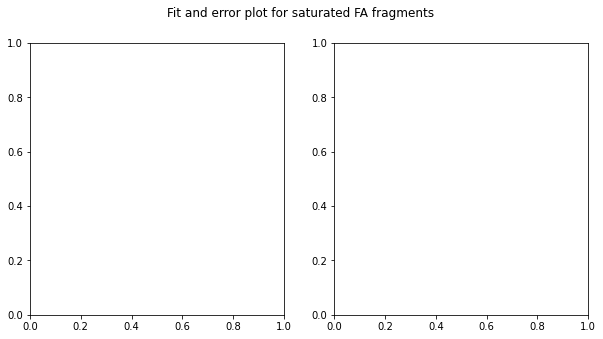

In [20]:
## range of nce
nce = [10,70]
FA_Cs_oi = [12, 18, 24]
FA_DBs_oi = [0, 0, 0]
FA_iso_oi = [0, 0, 0]

num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

# plt.figure(figsize=(10,5))
fig.suptitle("Fit and error plot for saturated FA fragments")

for i in np.arange(0,len(FA_Cs_oi),1):
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)

    eval_points = np.zeros((num_points_in_grid, 4))
    eval_points[:,0] = xvals ## NCE
    eval_points[:,1] = np.full((1,61), FA_Cs_oi[i]) ## FA_C
    eval_points[:,2] = FA_DBs_oi[i]
    eval_points[:,3] = FA_iso_oi[i]

    eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, np.array([10., 12.,  0.,  0.]), np.array([71., 33.,  7., 15.]))

    ax[0].plot(xvals, pow(2,eval_vals), label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])), color=colors[i][0])

    condition = ((df.FA_C_y == FA_Cs_oi[i]) & (df.FA_DB_y == FA_DBs_oi[i]) & (df.FA_iso_y == FA_iso_oi[i]))

    if condition.sum() > 0:
        ax[0].plot(df[condition].CE, df[condition].norm_Intensity, '.', alpha=.5, color=colors[i][0])
        tmp = (df[condition].norm_Intensity-pow(2,eval_vals[0:len(df[condition].norm_Intensity)]))/pow(2,eval_vals[0:len(df[condition].norm_Intensity)])*100
        av = ((tmp[(df[condition].CE >= 20) & (df[condition].CE <= 35)]).mean())
        # ax[1].plot(xvals[0:len(df[condition].norm_Intensity)], tmp, label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+' ('+str(round(av, 1))+')'), color=colors[i][0])
        ax[1].plot(xvals[0:len(df[condition].norm_Intensity)], tmp, label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+' ('+str(round(av, 1))+')'), color=colors[i][0])


    ax[0].legend()
    ax[0].set_xlabel("Normalized collision energy, %")
    ax[0].set_ylabel("Normalized intensity, %")
    ax[0].set_title("Measured and fitted intensity")


    ax[1].set_ylim(-25,25)
    ax[1].legend()
    ax[1].set_xlabel("Normalized collision energy, %")
    ax[1].set_ylabel("Relative error, %")
    ax[1].set_title("Difference between measured and fitted data")

RectangleSelector(ax[0], [20,30,10,20])

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FAsat.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

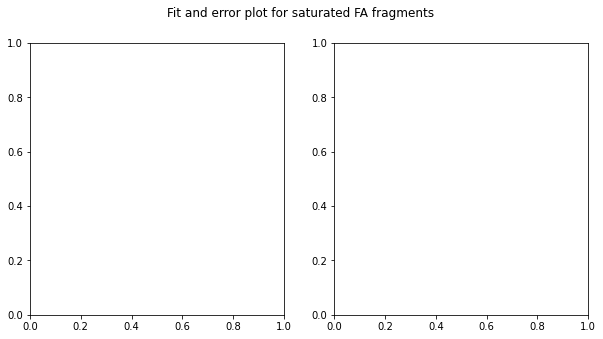

In [21]:
## range of nce
nce = [10,70]
FA_Cs_oi = [20]
FA_DBs_oi = [5]
FA_iso_oi = [5]

num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

# plt.figure(figsize=(10,5))
fig.suptitle("Fit and error plot for saturated FA fragments")

for i in np.arange(0,len(FA_Cs_oi),1):
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)

    eval_points = np.zeros((num_points_in_grid, 4))
    eval_points[:,0] = xvals ## NCE
    eval_points[:,1] = np.full((1,61), FA_Cs_oi[i]) ## FA_C
    eval_points[:,2] = FA_DBs_oi[i]
    eval_points[:,3] = FA_iso_oi[i]

    eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, np.array([10., 12.,  0.,  0.]), np.array([71., 33.,  7., 15.]))

    ax[0].plot(xvals, pow(2,eval_vals), label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])), color=colors[i][0])

    condition = ((df.FA_C_y == FA_Cs_oi[i]) & (df.FA_DB_y == FA_DBs_oi[i]) & (df.FA_iso_y == FA_iso_oi[i]))

    if condition.sum() > 0:
        ax[0].plot(df[condition].CE, df[condition].norm_Intensity, '.', alpha=.5, color=colors[i][0])
        tmp = (df[condition].norm_Intensity-pow(2,eval_vals[0:len(df[condition].norm_Intensity)]))/pow(2,eval_vals[0:len(df[condition].norm_Intensity)])*100
        av = ((tmp[(df[condition].CE >= 20) & (df[condition].CE <= 35)]).mean())
        # ax[1].plot(xvals[0:len(df[condition].norm_Intensity)], tmp, label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+' ('+str(round(av, 1))+')'), color=colors[i][0])
        ax[1].plot(xvals[0:len(df[condition].norm_Intensity)], tmp, label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+' ('+str(round(av, 1))+')'), color=colors[i][0])


    ax[0].legend()
    ax[0].set_xlabel("Normalized collision energy, %")
    ax[0].set_ylabel("Normalized intensity, %")
    ax[0].set_title("Measured and fitted intensity")
    ax[0].set_xlim(10,50)


    ax[1].set_ylim(-25,25)
    ax[1].legend()
    ax[1].set_xlabel("Normalized collision energy, %")
    ax[1].set_ylabel("Relative error, %")
    ax[1].set_title("Difference between measured and fitted data")

RectangleSelector(ax[0], [20,30,10,20])

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FA205.pdf")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

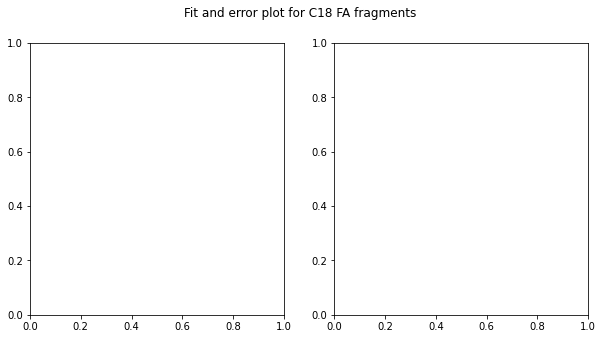

In [22]:
## range of nce
nce = [10,70]
FA_Cs_oi = np.full((1,6), 18).tolist()[0]
FA_DBs_oi = [0, 1, 2, 3, 3, 4]
FA_iso_oi = [0, 9, 9, 6, 9, 8]

num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

# plt.figure(figsize=(10,5))
fig.suptitle("Fit and error plot for C18 FA fragments")

for i in np.arange(0,len(FA_Cs_oi),1):
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)

    eval_points = np.zeros((num_points_in_grid, 4))
    eval_points[:,0] = xvals ## NCE
    eval_points[:,1] = np.full((1,61), FA_Cs_oi[i]) ## FA_C
    eval_points[:,2] = FA_DBs_oi[i]
    eval_points[:,3] = FA_iso_oi[i]


    eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, np.array([10., 12.,  0.,  0.]), np.array([71., 33.,  7., 15.]))

    ax[0].plot(xvals, pow(2,eval_vals), label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+'('+str(FA_iso_oi[i])+'z)'), color=colors[i][0])

    condition = ((df.FA_C_y == FA_Cs_oi[i]) & (df.FA_DB_y == FA_DBs_oi[i]) & (df.FA_iso_y == FA_iso_oi[i]))
    if condition.sum() > 0:
        ax[0].plot(df[condition].CE, df[condition].norm_Intensity, '.', alpha=.5, color=colors[i][0])

        tmp = (df[condition].norm_Intensity-pow(2,eval_vals)[0:len(df[condition].norm_Intensity)])/pow(2,eval_vals)[0:len(df[condition].norm_Intensity)]*100
        av = ((tmp[(df[condition].CE >= 20) & (df[condition].CE <= 35)]).mean())
        ax[1].plot(xvals[0:len(df[condition].norm_Intensity)], tmp, label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+'('+str(FA_iso_oi[i])+'z)'+' ('+str(round(av, 1))+')'), color=colors[i][0])

    ax[0].legend()
    ax[0].set_xlabel("Normalized collision energy, %")
    ax[0].set_ylabel("Normalized intensity, %")
    ax[0].set_title("Measured and fitted intensity")


    ax[1].set_ylim(-25,25)
    ax[1].legend()
    ax[1].set_xlabel("Normalized collision energy, %")
    ax[1].set_ylabel("Relative error, %")
    ax[1].set_title("Difference between measured and fitted data")

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FAC18.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

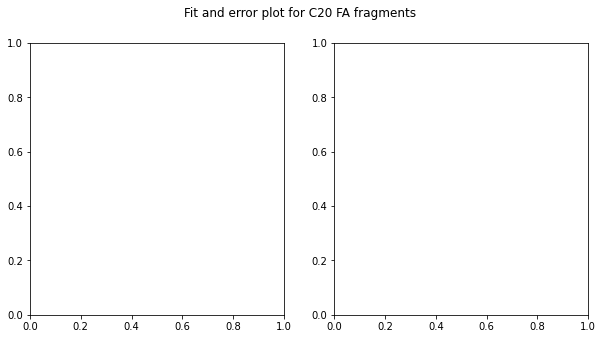

In [23]:
## range of nce
nce = [10,70]
FA_Cs_oi = np.full((1,7), 20).tolist()[0]
FA_DBs_oi = [0, 2, 3, 3, 4, 4, 5]
FA_iso_oi = [0, 5, 5, 11, 5, 8, 5]

num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

# plt.figure(figsize=(10,5))
fig.suptitle("Fit and error plot for C20 FA fragments")

for i in np.arange(0,len(FA_Cs_oi),1):
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)

    eval_points = np.zeros((num_points_in_grid, 4))
    eval_points[:,0] = xvals ## NCE
    eval_points[:,1] = np.full((1,61), FA_Cs_oi[i]) ## FA_C
    eval_points[:,2] = FA_DBs_oi[i]
    eval_points[:,3] = FA_iso_oi[i]


    eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, np.array([10., 12.,  0.,  0.]), np.array([71., 33.,  7., 15.]))

    ax[0].plot(xvals, pow(2,eval_vals), label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+'('+str(FA_iso_oi[i])+'z)'), color=colors[i][0])

    condition = ((df.FA_C_y == FA_Cs_oi[i]) & (df.FA_DB_y == FA_DBs_oi[i]) & (df.FA_iso_y == FA_iso_oi[i]))
    if condition.sum() > 0:
        ax[0].plot(df[condition].CE, df[condition].norm_Intensity, '.', alpha=.5, color=colors[i][0])

        tmp = (df[condition].norm_Intensity-pow(2,eval_vals)[0:len(df[condition].norm_Intensity)])/pow(2,eval_vals)[0:len(df[condition].norm_Intensity)]*100
        av = ((tmp[(df[condition].CE >= 20) & (df[condition].CE <= 35)]).mean())
        ax[1].plot(xvals[0:len(pow(2,df[condition].norm_Intensity))], tmp, label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+'('+str(FA_iso_oi[i])+'z)'+' ('+str(round(av, 1))+')'), color=colors[i][0])

    ax[0].legend()
    ax[0].set_xlabel("Normalized collision energy, %")
    ax[0].set_ylabel("Normalized intensity, %")
    ax[0].set_title("Measured and fitted intensity")


    ax[1].set_ylim(-25,25)
    ax[1].legend()
    ax[1].set_xlabel("Normalized collision energy, %")
    ax[1].set_ylabel("Relative error, %")
    ax[1].set_title("Difference between measured and fitted data")

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FAC20.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

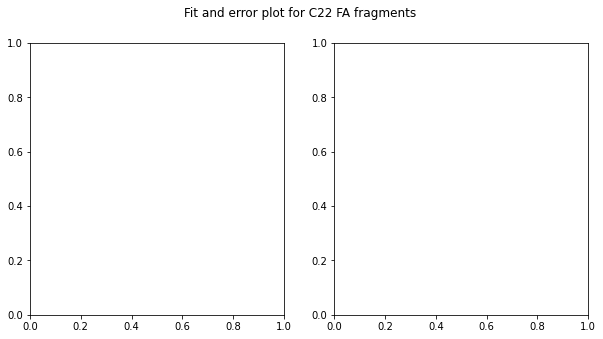

In [24]:
## range of nce
nce = [10,70]
FA_Cs_oi = np.full((1,8), 22).tolist()[0]
FA_DBs_oi = [0, 0, 2, 3, 4, 5, 5, 6]
FA_iso_oi = [0, 13, 13, 13, 7, 4, 11, 4]

num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

# plt.figure(figsize=(10,5))
fig.suptitle("Fit and error plot for C22 FA fragments")

for i in np.arange(0,len(FA_Cs_oi),1):
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)

    eval_points = np.zeros((num_points_in_grid, 4))
    eval_points[:,0] = xvals ## NCE
    eval_points[:,1] = np.full((1,61), FA_Cs_oi[i]) ## FA_C
    eval_points[:,2] = FA_DBs_oi[i]
    eval_points[:,3] = FA_iso_oi[i]


    eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, np.array([10., 12.,  0.,  0.]), np.array([71., 33.,  7., 15.]))

    ax[0].plot(xvals, pow(2,eval_vals), label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+'('+str(FA_iso_oi[i])+'z)'), color=colors[i][0])

    condition = ((df.FA_C_y == FA_Cs_oi[i]) & (df.FA_DB_y == FA_DBs_oi[i]) & (df.FA_iso_y == FA_iso_oi[i]))
    if condition.sum() > 0:
        ax[0].plot(df[condition].CE, df[condition].norm_Intensity, '.', alpha=.5, color=colors[i][0])

        tmp = (df[condition].norm_Intensity-pow(2,eval_vals)[0:len(df[condition].norm_Intensity)])/pow(2,eval_vals)[0:len(df[condition].norm_Intensity)]*100
        av = ((tmp[(df[condition].CE >= 20) & (df[condition].CE <= 35)]).mean())
        ax[1].plot(xvals[0:len(df[condition].norm_Intensity)], tmp, label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+'('+str(FA_iso_oi[i])+'z)'+' ('+str(round(av, 1))+')'), color=colors[i][0])

    ax[0].legend()
    ax[0].set_xlabel("Normalized collision energy, %")
    ax[0].set_ylabel("Normalized intensity, %")
    ax[0].set_title("Measured and fitted intensity")


    ax[1].set_ylim(-25,25)
    ax[1].legend()
    ax[1].set_xlabel("Normalized collision energy, %")
    ax[1].set_ylabel("Relative error, %")
    ax[1].set_title("Difference between measured and fitted data")

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FAC22.jpg")
plt.show()

NameError: name 'sparse_poly_model_pco' is not defined

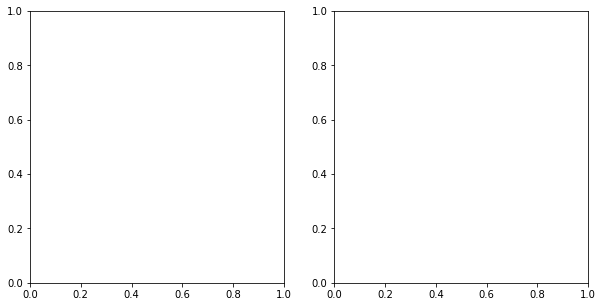

In [25]:
## range of nce
nce = [10,70]
FA_Cs_oi = [22, 22, 24, 26, 28, 32]
FA_DBs_oi = [0, 6, 6, 6, 6, 6]
FA_iso_oi = [0, 4, 6, 8, 10, 14]

num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

# plt.figure(figsize=(10,5))
# fig.suptitle("Fit and error plot for FA fragments with 6 DB")

for i in np.arange(0,len(FA_Cs_oi),1):
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)

    eval_points = np.zeros((num_points_in_grid, 4))
    eval_points[:,0] = xvals ## NCE
    eval_points[:,1] = np.full((1,61), FA_Cs_oi[i]) ## FA_C
    eval_points[:,2] = FA_DBs_oi[i]
    eval_points[:,3] = FA_iso_oi[i]


    eval_vals = poly_evaluate_at(sparse_poly_model_pco, eval_points, np.array([10., 12.,  0.,  0.]), np.array([71., 33.,  7., 15.]))

    ax[0].plot(xvals, pow(2,eval_vals), label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+'('+str(FA_iso_oi[i])+'z)'), color=colors[i][0])

    condition = ((df.FA_C_y == FA_Cs_oi[i]) & (df.FA_DB_y == FA_DBs_oi[i]) & (df.FA_iso_y == FA_iso_oi[i]))
    if condition.sum() > 0:
        ax[0].plot(df[condition].CE, df[condition].norm_Intensity, '.', alpha=.5, color=colors[i][0])

        tmp = (df[condition].norm_Intensity-pow(2,eval_vals)[0:len(df[condition].norm_Intensity)])/pow(2,eval_vals)[0:len(df[condition].norm_Intensity)]*100
        av = ((tmp[(df[condition].CE >= 20) & (df[condition].CE <= 35)]).mean())
        ax[1].plot(xvals[0:len(df[condition].norm_Intensity)], tmp, label=('FA '+str(FA_Cs_oi[i])+':'+str(FA_DBs_oi[i])+'('+str(FA_iso_oi[i])+'z)'+' ('+str(round(av, 1))+')'), color=colors[i][0])

    ax[0].legend()
    ax[0].set_xlabel("Normalized collision energy, %")
    ax[0].set_ylabel("Normalized intensity, %")
    ax[0].set_title("Measured and fitted intensity")


    ax[1].set_ylim(-25,25)
    ax[1].legend()
    ax[1].set_xlabel("Normalized collision energy, %")
    ax[1].set_ylabel("Relative error, %")
    ax[1].set_title("Difference between measured and fitted data")

plt.tight_layout()
plt.savefig("./figures/paper_draft/20220530_PCO_fullset_FA6DB.pdf")
plt.show()

## Equation

In [26]:
from minterpy.pointcloud_utils import *

pco_model_can = mp.get_transformation(sparse_poly_model_pco, mp.CanonicalPolynomial)()

trimmed_coeffs = pco_model_can.coeffs.copy()
# trimmed_coeffs[np.where((trimmed_coeffs<1e0) & (trimmed_coeffs>-1e0))] = 0.0

# trimmed_coeffs = np.around(trimmed_coeffs, 2)
pco_model_can.coeffs = trimmed_coeffs

pco_model_eqn = mp_to_sympy(pco_model_can)

pco_model_eqn

ModuleNotFoundError: No module named 'minterpy.pointcloud_utils'

## Save the polynomial function as pickle

In [27]:
import pickle

# write polynomial coefficients and exponents to dictionary for export

# poly_info = {'coeffs': sparse_poly_model_pco_sn1.coeffs, 'exponents': sparse_poly_model_pco_sn1.multi_index.exponents}
poly_info = {'coeffs': sparse_poly_model_pco.coeffs, 'exponents': sparse_poly_model_pco.multi_index.exponents, 'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

## Storing the polynomial object in a file

# pickle.dump(poly_info, open('20230629_PCOsn2_FA_poly', 'ab'))

NameError: name 'sparse_poly_model_pco' is not defined

List of unique FA features in PCO data set

In [28]:
unique_CONL = np.array(df[df.CE == 25].loc[:,['FA_C_y', 'FA_DB_y', 'FA_iso_y']].sort_values(by=('FA_DB_y')).sort_values(by=('FA_C_y')).reset_index(drop=True))

In [29]:
poly_info

NameError: name 'poly_info' is not defined